<a href="https://colab.research.google.com/github/Segn11/dataset-analysis-and-manipulation/blob/prediction/tanzania_upd17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv('/content/Train (2).csv')
test_df = pd.read_csv('/content/Test (1).csv')

In [ ]:
print(train_df.shape)


train_df.head()



(4809, 23)


,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [ ]:
print(test_df.shape)
test_df.head()

(4809, 23)


,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [ ]:
train_df.columns

Index(['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing'],
      dtype='object')

In [ ]:
test_df.columns

Index(['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing',
       'total_cost'],
      dtype='object')

In [ ]:
train_df.isnull().sum() / len(train_df) * 100




,0
ID,0.000000
country,0.000000
age_group,0.000000
travel_with,23.164899
total_female,0.062383
total_male,0.103972
purpose,0.000000
main_activity,0.000000
info_source,0.000000
tour_arrangement,0.000000


In [ ]:
test_df.isnull().sum() / len(test_df) * 100


,0
ID,0.000000
country,0.000000
age_group,0.000000
travel_with,20.424735
total_female,0.062461
total_male,0.124922
purpose,0.000000
main_activity,0.000000
info_source,0.000000
tour_arrangement,0.000000


In [ ]:
if "total_cost" in train_df.columns:
    print("true")
else:
    print("false"  )

true


In [ ]:
Q1 = train_df['total_cost'].quantile(0.25)
Q3 = train_df['total_cost'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df['total_cost'] < lower_bound) | (train_df['total_cost'] > upper_bound)]
print("Number of outliers:", len(outliers))


Number of outliers: 424


In [ ]:
train_df = train_df[(train_df['total_cost'] >= lower_bound) & (train_df['total_cost'] <= upper_bound)]
print("New train shape:", train_df.shape)


New train shape: (4385, 23)


In [ ]:
test_df = test_df[(train_df['total_cost'] >= lower_bound) & (train_df['total_cost'] <= upper_bound)]
print("New train shape:", test_df.shape)

In [ ]:
if "total_cost" in train_df.columns:
    print("true")
else:
    print("false"  )

true


In [ ]:
categorical_cols = train_df.select_dtypes(include='object').columns

In [ ]:
#Count unique values for each
cardinality = train_df[categorical_cols].nunique().sort_values()
print(cardinality)

tour_arrangement            2
package_insurance           2
package_guided_tour         2
package_sightseeing         2
package_transport_tz        2
package_food                2
package_accomodation        2
package_transport_int       2
first_trip_tz               2
age_group                   4
payment_mode                4
travel_with                 5
most_impressing             7
purpose                     7
info_source                 8
main_activity               9
country                   105
ID                       4809
dtype: int64


In [ ]:
numerical = train_df.select_dtypes(include='number').columns
print(numerical)

Index(['total_female', 'total_male', 'night_mainland', 'night_zanzibar',
       'total_cost'],
      dtype='object')


In [ ]:
leakage_cols = ['most_impressing', 'payment_mode', 'night_mainland', 'night_zanzibar']
train_df.drop(columns=leakage_cols, inplace=True)
test_df.drop(columns=leakage_cols, inplace=True)


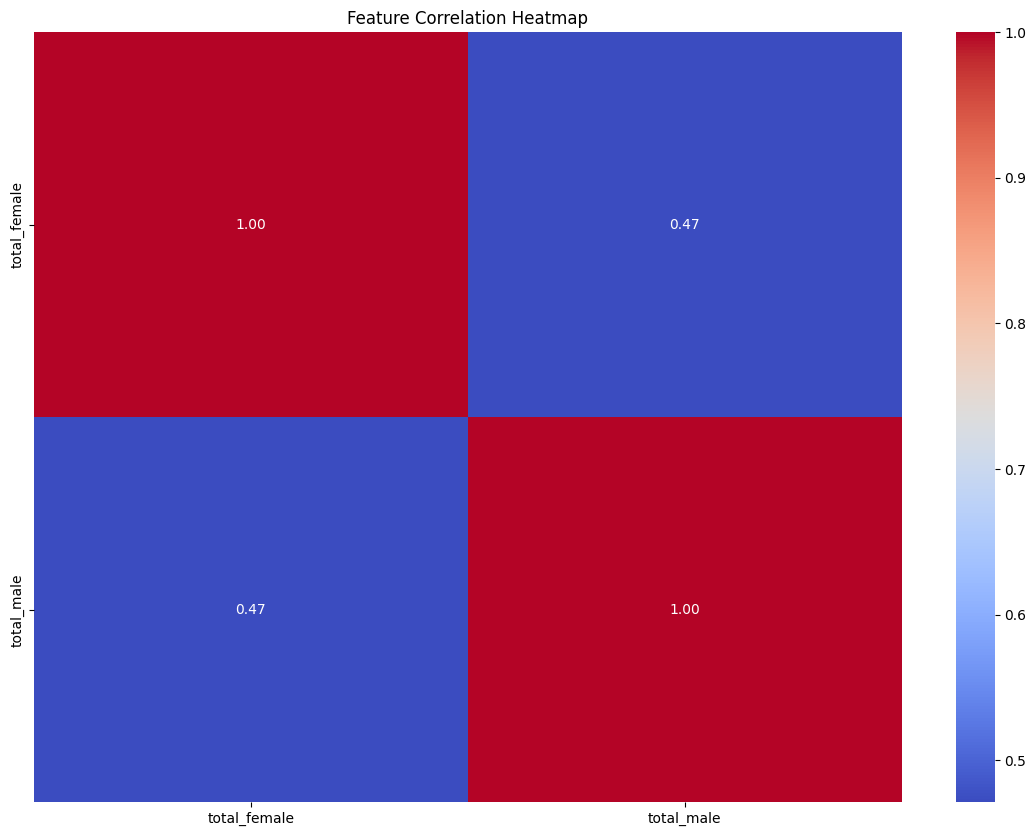

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only numeric columns (excluding target)
numeric_cols = train_df.select_dtypes(include=['number']).drop(columns=['total_cost'], errors='ignore')

# Correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
# Separate features and target variable
X = train_df.drop(columns=['ID', 'total_cost'])
y = train_df['total_cost']


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [ ]:
X_test = test_df.drop(columns=['ID'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3847, 17)
y_train shape: (3847,)
X_test shape: (962, 17)
y_test shape: (962,)


In [ ]:
y_mean = y.mean()

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Compute the mean of the target
y_mean = y.mean()

# Create an array where every prediction is the mean
y_pred_baseline = np.full(shape=len(y), fill_value=y_mean)

# Print mean and MAE
print("Mean:", round(y_mean, 2))
print("MAE:", mean_absolute_error(y, y_pred_baseline))


Mean: 8114388.78
MAE: 8037567.648106387


In [ ]:
!pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.6 MB/s eta 0:00:00


In [ ]:
from category_encoders import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    OneHotEncoder(use_cat_names=True),  # encode categorical features
    SimpleImputer(strategy='mean'),    # fill missing values
    StandardScaler(),                   # scale all features
    Ridge()                             # linear regression model
)


In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['country', 'age_group', 'travel_with',
                                     'purpose', 'main_activity', 'info_source',
                                     'tour_arrangement',
                                     'package_transport_int',
                                     'package_accomodation', 'package_food',
                                     'package_transport_tz',
                                     'package_sightseeing',
                                     'package_guided_tour', 'package_insurance',
                                     'first_trip_tz'],
                               use_cat_names=True)),
                ('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
y_pred_training = model.predict(X_train)
print("Training MAE:", mean_absolute_error(y_train, y_pred_training))

Training MAE: 5734708.16776548


In [ ]:
# Get columns from training data
train_cols = X.columns

# Select only these columns from test set
X_submit = test_df[train_cols]

# Predict
test_preds = model.predict(X_submit)


In [ ]:
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'total_cost': test_preds
})

submission.to_csv('submission.csv', index=False)
print("🎯 Submission file created: submission.csv")


🎯 Submission file created: submission.csv


In [ ]:
from google.colab import files

# Download the submission file
files.download('submission.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

# -------------------------
# 1. Load Data
# -------------------------
train_df = pd.read_csv('/content/Train (2).csv')
test_df = pd.read_csv('/content/Test (1).csv')

# Drop leakage columns
leakage_cols = ['most_impressing', 'payment_mode', 'night_mainland', 'night_zanzibar']
train_df.drop(columns=leakage_cols, inplace=True)
test_df.drop(columns=leakage_cols, inplace=True)

# -------------------------
# 2. Separate features and target
# -------------------------
X = train_df.drop(columns=['ID', 'total_cost'])
y = train_df['total_cost']

# -------------------------
# 3. Identify categorical and numerical columns
# -------------------------
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# -------------------------
# 4. Handle missing values
# -------------------------
# Numeric columns: median imputation
num_imputer = SimpleImputer(strategy='median')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
test_df[numerical_cols] = num_imputer.transform(test_df[numerical_cols])

# Categorical columns: fill missing with mode
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])
    test_df[col] = test_df[col].fillna(X[col].mode()[0])

# -------------------------
# 5. Target Encoding for categoricals
# -------------------------
te = TargetEncoder(cols=categorical_cols)
X[categorical_cols] = te.fit_transform(X[categorical_cols], y)
test_df[categorical_cols] = te.transform(test_df[categorical_cols])

# -------------------------
# 6. Train/Validation Split
# -------------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 7. Define Models
# -------------------------
xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=100
)

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    eval_metric='MAE',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

# -------------------------
# 8. Train Models
# -------------------------
print("Training XGBoost...")
xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=100)

print("Training LightGBM...")
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='l1',  # l1 = MAE
    callbacks=[lgb.log_evaluation(100)]  # verbose every 100 rounds
)

print("Training CatBoost...")
cat_model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

# -------------------------
# 9. Ensemble Predictions (average)
# -------------------------
xgb_pred = xgb_model.predict(X_valid)
lgb_pred = lgb_model.predict(X_valid)
cat_pred = cat_model.predict(X_valid)

y_val_pred = (xgb_pred + lgb_pred + cat_pred) / 3
val_mae = mean_absolute_error(y_valid, y_val_pred)
print(f"Validation MAE (Ensemble): {val_mae:.2f}")

# -------------------------
# 10. Predict on Test Set
# -------------------------
xgb_test = xgb_model.predict(test_df[X.columns])
lgb_test = lgb_model.predict(test_df[X.columns])
cat_test = cat_model.predict(test_df[X.columns])

test_preds = (xgb_test + lgb_test + cat_test) / 3

# -------------------------a
# 11. Create Submission
# -------------------------
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'total_cost': test_preds
})
submission.to_csv('submission.csv', index=False)
print("🎯 Submission file created: submission.csv")


Training XGBoost...
[0]	validation_0-rmse:11646620.53844
[100]	validation_0-rmse:9177044.97463
[157]	validation_0-rmse:9313389.64594
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 158
[LightGBM] [Info] Number of data points in the train set: 3847, number of used features: 17
[LightGBM] [Info] Start training from score 8197220.083608
[100]	valid_0's l1: 4.90678e+06	valid_0's l2: 8.02269e+13
[200]	valid_0's l1: 5.01871e+06	valid_0's l2: 8.32723e+13
[300]	valid_0's l1: 5.14037e+06	valid_0's l2: 8.65394e+13
[400]	valid_0's l1: 5.22824e+06	valid_0's l2: 8.88925e+13
[500]	valid_0's l1: 5.28999e+06	valid_0's l2: 9.06015e+13
[600]	valid_0's l1: 5.34983e+06	valid_0's l2: 9.21987e+13
[700]	valid_0's l1: 5.37131e+06	valid_0's l2: 9.31316e+13
[800]	valid_0's l1: 5.4062e+06

In [ ]:
from google.colab import files

# Download the submission file
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>